In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

2026-06-04 10:15:40.597810: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 10:15:40.605133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780568140.614042   37357 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780568140.616841   37357 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 10:15:40.626838: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,   # <-- explícito
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780568142.677534   37357 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Verificación: rango de píxeles
image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    ViT con cabeza de clasificación binaria.
    backbone.trainable = False  solo se entrena la cabeza.
    """
 
    base_model = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet21k")
    base_model.trainable = False

    image_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name = "images")
    vit_output = base_model(image_input)
    cls_token = vit_output[:, 0, :]

    x = layers.BatchNormalization()(cls_token)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    output = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs=image_input, outputs=output, name="ViT")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

Model: "ViT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,802,497 (327.31 MB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 85,800,192 (327.30 MB)


Parámetros entrenables: 2,305 / 85,802,497 (0.0%)


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model_vit_finetuning.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

hist = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1780568150.308135   39122 service.cc:148] XLA service 0x79b054003e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780568150.308177   39122 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-04 10:15:53.942341: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780568158.600747   39122 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 10:16:00.019176: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 276 bytes spill stores, 276 bytes spill loads

2026-06-04 10:16:00.054438: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_149', 132 bytes 

   3/1197 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.4878 - auc: 0.4773 - loss: 0.9035   

I0000 00:00:1780568163.122048   39122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 103/1197 ━━━━━━━━━━━━━━━━━━━━ 2:16 125ms/step - accuracy: 0.5968 - auc: 0.6228 - loss: 0.7401

...

1097/1197 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.7243 - auc: 0.7975 - loss: 0.5447

Corrupt JPEG data: premature end of data segment


1131/1197 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.7244 - auc: 0.7976 - loss: 0.5446

2026-06-04 11:51:12.941791: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1196/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.7245 - auc: 0.7976 - loss: 0.5445
Epoch 24: val_auc did not improve from 0.81479

Epoch 24: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 236s 197ms/step - accuracy: 0.7264 - auc: 0.7987 - loss: 0.5427 - val_accuracy: 0.7301 - val_auc: 0.8147 - val_loss: 0.5306 - learning_rate: 1.5625e-05
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.


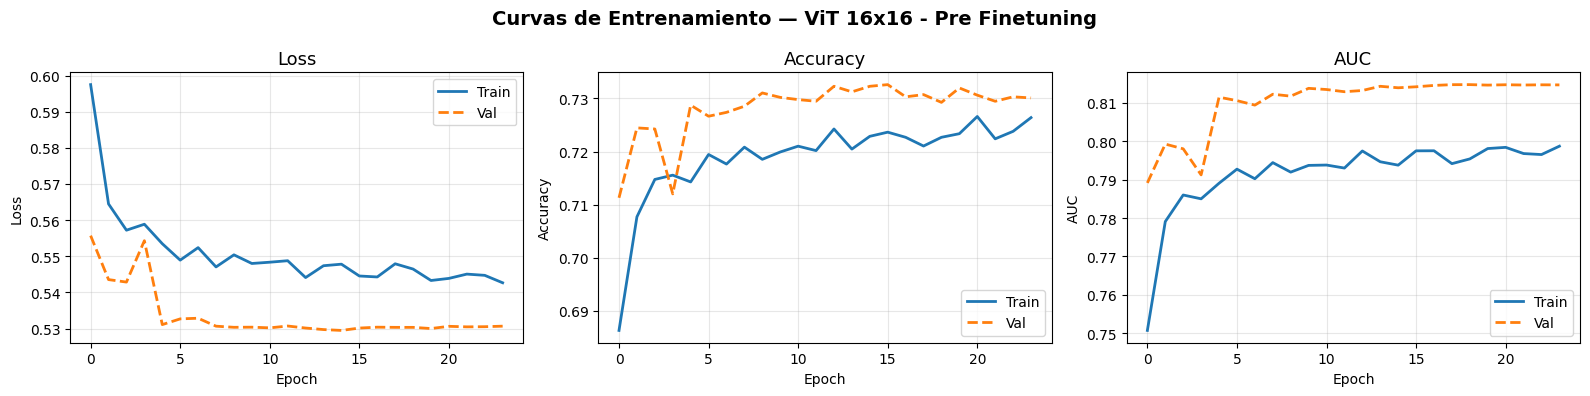

In [7]:
def plot_history(hist, figure_name, figure_title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — ViT 16x16 - Pre Finetuning', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figure_name, dpi=150, bbox_inches='tight')
    plt.show()

fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_vit_prefinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — ViT 16x16 - Pre Finetuning'
plot_history(hist, fig_name, fig_title)

In [8]:
print("=" * 45)
print("EVALUACIÓN FINAL SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN FINAL SOBRE TEST SET
 15/374 ━━━━━━━━━━━━━━━━━━━━ 1:12 202ms/step - accuracy: 0.7465 - auc: 0.8139 - loss: 0.5281

2026-06-04 11:51:35.122001: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


139/374 ━━━━━━━━━━━━━━━━━━━━ 40s 173ms/step - accuracy: 0.7289 - auc: 0.8153 - loss: 0.5269

Corrupt JPEG data: premature end of data segment


337/374 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.7293 - auc: 0.8140 - loss: 0.5296

2026-06-04 11:52:29.523450: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


372/374 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7296 - auc: 0.8141 - loss: 0.5296

2026-06-04 11:52:35.364598: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 132 bytes spill stores, 132 bytes spill loads

2026-06-04 11:52:35.950459: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 11:52:36.166141: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 11:52:36.368211: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 884 bytes spill stores, 884 bytes spill loads

2026-06-04 11:52:36.377379: I external/local_xla/xla/stream_executor

374/374 ━━━━━━━━━━━━━━━━━━━━ 65s 175ms/step - accuracy: 0.7331 - auc: 0.8161 - loss: 0.5282

Loss:     0.5282
Accuracy: 0.7331  (73.31%)
AUC:      0.8161


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

Distribución y_true: [5970 5995]
Distribución y_pred: [5482 6483]


2026-06-04 11:52:51.328854: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


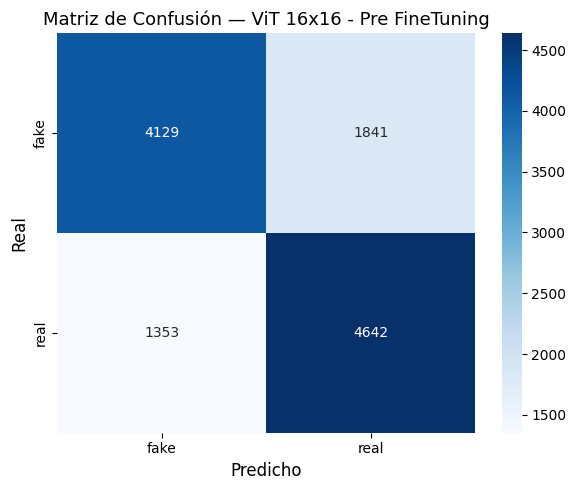


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.75      0.69      0.72      5970
        real       0.72      0.77      0.74      5995

    accuracy                           0.73     11965
   macro avg       0.73      0.73      0.73     11965
weighted avg       0.73      0.73      0.73     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — ViT 16x16 - Pre FineTuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_vit_prefinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


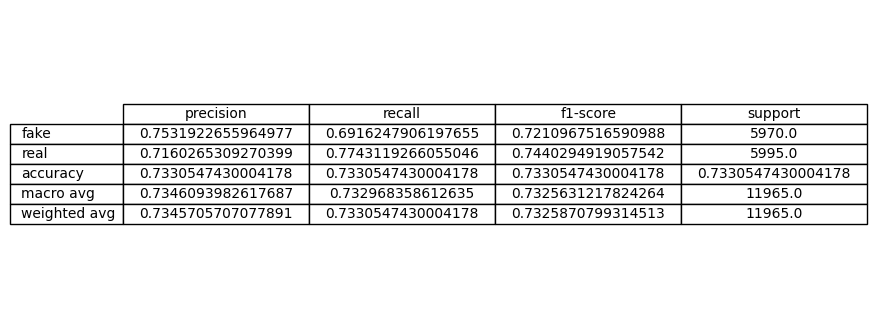

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_vit_prefinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

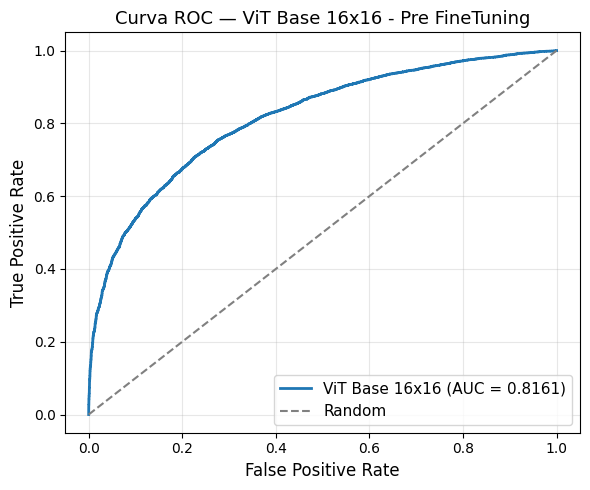

AUC final (test completo): 0.8161


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ViT Base 16x16 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — ViT Base 16x16 - Pre FineTuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_vit_prefinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")

In [ ]:
vit_model = model.get_layer("vi_t_backbone")
vit_model.trainable = True
encoder = vit_model.get_layer("vit_encoder")

for block in encoder.encoder_layers:
    block.trainable = False

vit_model.get_layer("vit_patching_and_embedding").trainable = False

trainable_layers = [10,11]

for i, block in enumerate(encoder.encoder_layers):
    if i in trainable_layers:
        block.trainable = True

encoder.layer_norm.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

trainable_vit = sum([1 for l in encoder.encoder_layers if l.trainable])
frozen_vit   = sum([1 for l in encoder.encoder_layers if not l.trainable])
print(f"Capas entrenables ViT: {trainable_vit} | Congeladas ViT: {frozen_vit}")

trainable_ft = sum(np.prod(v.shape) for v in encoder.weights)
print(f"Parámetros entrenables en fine-tuning: {trainable_ft:,}")

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(
        "best_model_finetuned.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
]

Capas entrenables ViT: 2 | Congeladas ViT: 10
Parámetros entrenables en fine-tuning: 85,056,000


In [ ]:
hist_ft = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_ft
)

print("\n=" * 45)
print("EVALUACIÓN FINAL TRAS FINE-TUNING")
print("=" * 45)
model.evaluate(test_ds)

Epoch 1/10


2026-06-04 11:53:06.526651: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_209', 1712 bytes spill stores, 1200 bytes spill loads

2026-06-04 11:53:06.863883: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_105', 384 bytes spill stores, 384 bytes spill loads

2026-06-04 11:53:07.042511: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_208', 548 bytes spill stores, 548 bytes spill loads

2026-06-04 11:53:07.520240: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_208', 80 bytes spill stores, 80 bytes spill loads

2026-06-04 11:53:07.550428: I external/local_xla/xla/str

 103/1197 ━━━━━━━━━━━━━━━━━━━━ 2:08 117ms/step - accuracy: 0.7121 - auc: 0.7921 - loss: 0.5545

2026-06-04 11:53:21.453840: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 120/1197 ━━━━━━━━━━━━━━━━━━━━ 2:21 132ms/step - accuracy: 0.7135 - auc: 0.7926 - loss: 0.5539

...

Corrupt JPEG data: premature end of data segment


1137/1197 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.7885 - auc: 0.8708 - loss: 0.4504

2026-06-04 12:32:33.769674: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1196/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7886 - auc: 0.8709 - loss: 0.4502
Epoch 10: val_auc improved from 0.88232 to 0.88403, saving model to best_model_finetuned.keras

Epoch 10: finished saving model to best_model_finetuned.keras
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 238s 198ms/step - accuracy: 0.7902 - auc: 0.8729 - loss: 0.4460 - val_accuracy: 0.7943 - val_auc: 0.8840 - val_loss: 0.4414
Restoring model weights from the end of the best epoch: 10.

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
EVALUACIÓN FINAL TRAS FINE-TUNING
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7928 - auc: 0.8808 - loss: 0.4450


[0.4450109899044037, 0.7928123474121094, 0.8808065056800842]

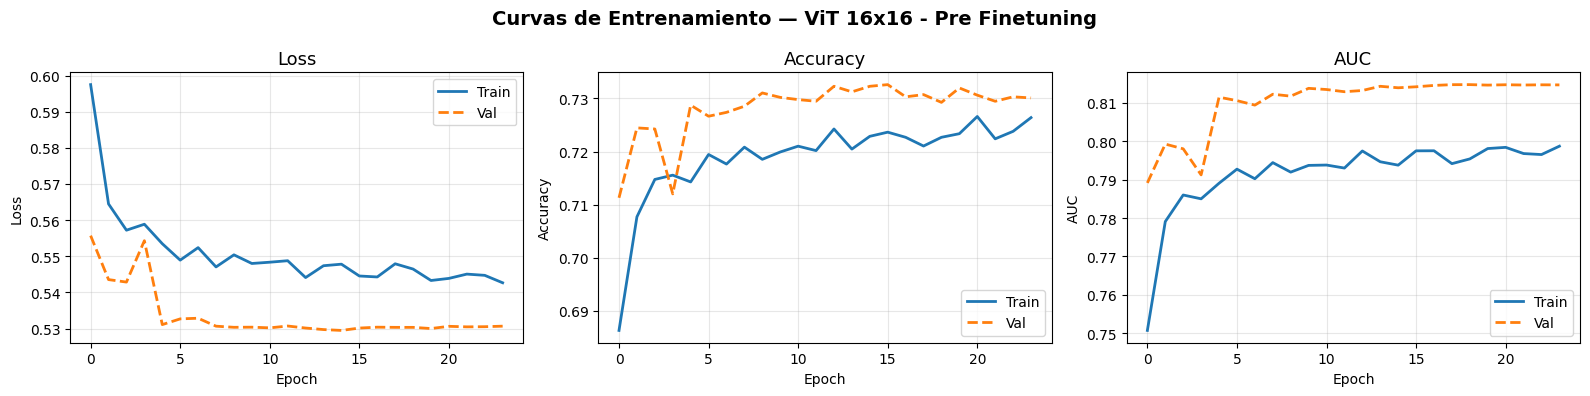

In [15]:
fig_name = '/workspace/imagenes_metricas_full_dataset/training_curves_vit_salida_postfinetuning_final.png'
fig_title = 'Curvas de Entrenamiento — ViT Base 16x16 - Post Finetuning'
plot_history(hist, fig_name, fig_title)

In [16]:
print("=" * 45)
print("EVALUACIÓN DESPUES DE FINE TUNING SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN DESPUES DE FINE TUNING SOBRE TEST SET
374/374 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7928 - auc: 0.8808 - loss: 0.4450

Loss:     0.4450
Accuracy: 0.7928  (79.28%)
AUC:      0.8808


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

Distribución y_true: [5970 5995]
Distribución y_pred: [5321 6644]


2026-06-04 12:33:28.355919: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


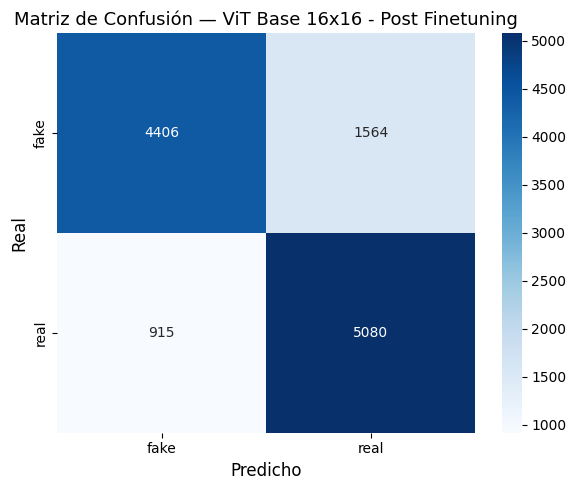


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.83      0.74      0.78      5970
        real       0.76      0.85      0.80      5995

    accuracy                           0.79     11965
   macro avg       0.80      0.79      0.79     11965
weighted avg       0.80      0.79      0.79     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — ViT Base 16x16 - Post Finetuning', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_vit_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


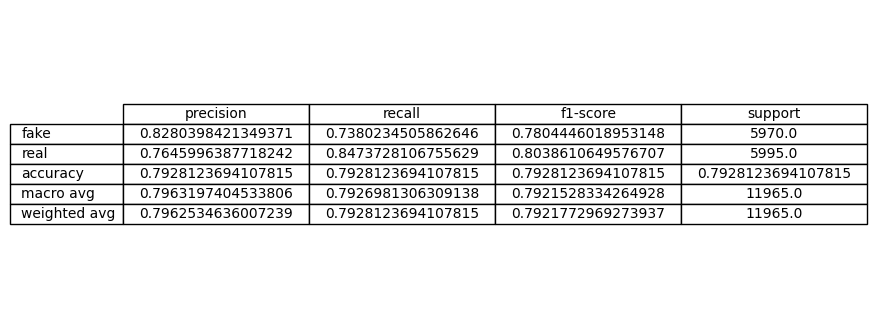

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_vit_postfinetuning_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

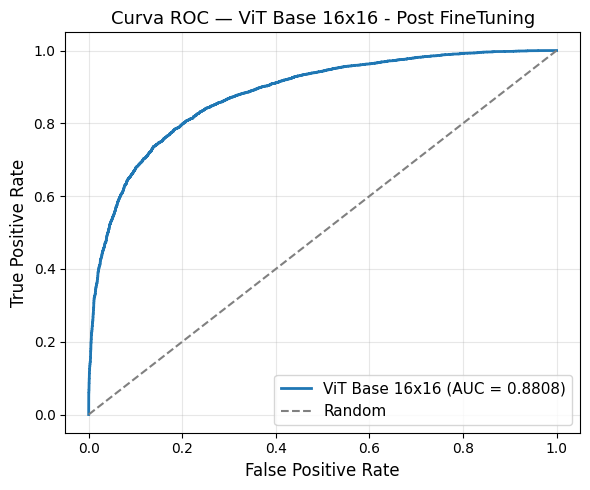

AUC final (test completo): 0.8808


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ViT Base 16x16 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — ViT Base 16x16 - Post FineTuning', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_vit_postfinetuning_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")